In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

sns.set_theme(style="whitegrid")

from pathlib import Path
BASE_DIR = Path.cwd().parent

RAW_DATA = BASE_DIR / "data" / "raw"
PROCESSED_DATA = BASE_DIR / "data" / "processed"

In [12]:
fund_master = pd.read_csv(
    RAW_DATA / "01_fund_master.csv"
)

nav_history = pd.read_csv(
    PROCESSED_DATA / "nav_history_cleaned.csv"
)

scheme_performance = pd.read_csv(
    PROCESSED_DATA / "scheme_performance_cleaned.csv"
)

investor_transactions = pd.read_csv(
    PROCESSED_DATA / "investor_transactions_cleaned.csv"
)

aum_by_fund_house = pd.read_csv(
    RAW_DATA / "03_aum_by_fund_house.csv"
)

monthly_sip_inflows = pd.read_csv(
    RAW_DATA / "04_monthly_sip_inflows.csv"
)

category_inflows = pd.read_csv(
    RAW_DATA / "05_category_inflows.csv"
)

industry_folio_count = pd.read_csv(
    RAW_DATA / "06_industry_folio_count.csv"
)

portfolio_holdings = pd.read_csv(
    RAW_DATA / "09_portfolio_holdings.csv"
)
benchmark_indices=pd.read_csv( RAW_DATA/"10_benchmark_indices.csv")

In [ ]:
#Compute daily returns

# Sort by fund and date
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

# Daily Return
nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


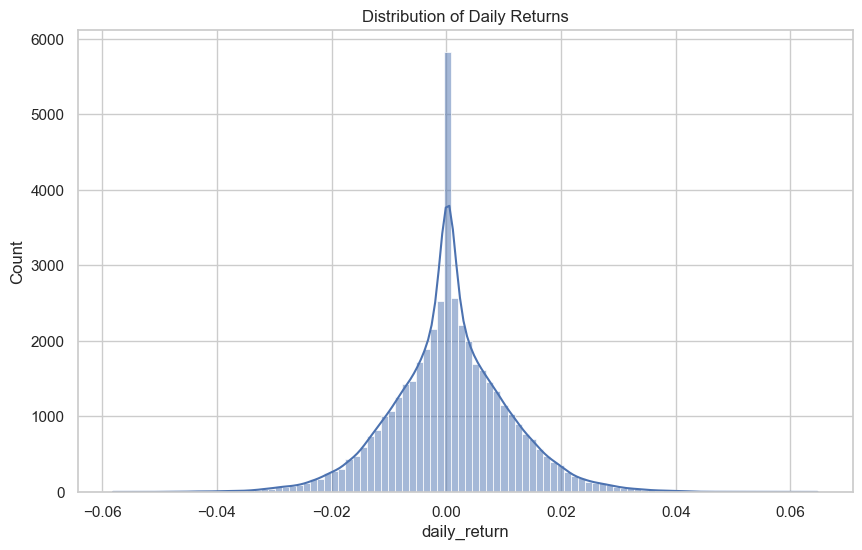

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [6]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

print(
    nav_history["daily_return"]
    .describe()
)

In [8]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)
cagr_results = []

for fund in nav_history["amfi_code"].unique():

    df = (
        nav_history[
            nav_history["amfi_code"] == fund
        ]
        .sort_values("date")
    )

    nav_start = df.iloc[0]["nav"]
    nav_end = df.iloc[-1]["nav"]

    years = (
        (df.iloc[-1]["date"] -
         df.iloc[0]["date"]).days
    ) / 365.25

    cagr = (
        (nav_end / nav_start)
        ** (1 / years)
        - 1
    )

    cagr_results.append(
        [fund, cagr]
    )

cagr_table = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr"]
)

cagr_table.head()

,amfi_code,cagr
0,100016,0.026371
1,100025,0.044582
2,100033,0.301232
3,101206,0.235384
4,101207,0.079388


In [9]:
rf = 0.065

sharpe_scores = []

for fund in nav_history["amfi_code"].unique():

    returns = (
        nav_history[
            nav_history["amfi_code"] == fund
        ]["daily_return"]
        .dropna()
    )

    sharpe = (
        (returns.mean()*252 - rf)
        /
        (returns.std())
    ) * np.sqrt(252)

    sharpe_scores.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_scores,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,364.969375
30,120843,329.299480
36,148569,311.202366
19,119551,304.483175
25,120505,297.385502


In [10]:
sortino_scores = []

for fund in nav_history["amfi_code"].unique():

    returns = (
        nav_history[
            nav_history["amfi_code"] == fund
        ]["daily_return"]
        .dropna()
    )

    downside = returns[
        returns < 0
    ]

    sortino = (
        (returns.mean()*252 - rf)
        /
        downside.std()
    ) * np.sqrt(252)

    sortino_scores.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_scores,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head()

,amfi_code,sortino_ratio
34,148567,601.182382
30,120843,595.808648
36,148569,541.022309
19,119551,539.347317
25,120505,511.396941


In [18]:
from scipy.stats import linregress

# Convert date
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

# Sort by fund and date
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

# Create daily returns
nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

# Prepare benchmark returns (Nifty 100)
benchmark_indices["date"] = pd.to_datetime(
    benchmark_indices["date"]
)

nifty100 = (
    benchmark_indices[
        benchmark_indices["index_name"] == "Nifty 100"
    ]
    .sort_values("date")
    .copy()
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

benchmark_returns = (
    nifty100["benchmark_return"]
    .dropna()
    .reset_index(drop=True)
)

# Alpha & Beta Calculation
alpha_beta = []

for fund in nav_history["amfi_code"].unique():

    fund_returns = (
        nav_history[
            nav_history["amfi_code"] == fund
        ]["daily_return"]
        .dropna()
        .reset_index(drop=True)
    )

    min_len = min(
        len(fund_returns),
        len(benchmark_returns)
    )

    beta, alpha, r, p, se = linregress(
        benchmark_returns[:min_len],
        fund_returns[:min_len]
    )

    alpha_beta.append(
        [
            fund,
            alpha * 252,
            beta
        ]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

# Tracking Error Calculation
tracking_error = []

for fund in nav_history["amfi_code"].unique():

    fund_returns = (
        nav_history[
            nav_history["amfi_code"] == fund
        ]["daily_return"]
        .dropna()
        .reset_index(drop=True)
    )

    min_len = min(
        len(fund_returns),
        len(benchmark_returns)
    )

    te = (
        (
            fund_returns[:min_len]
            -
            benchmark_returns[:min_len]
        )
        .std()
        * np.sqrt(252)
    )

    tracking_error.append(
        [fund, te]
    )

tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

print("Top Funds by Alpha")
display(
    alpha_beta_df.sort_values(
        "alpha",
        ascending=False
    ).head()
)

print("Lowest Tracking Error Funds")
display(
    tracking_error_df.sort_values(
        "tracking_error"
    ).head()
)

Top Funds by Alpha


C:\Users\SAYANDIP\AppData\Local\Temp\ipykernel_27052\3009339940.py:64: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  beta, alpha, r, p, se = linregress(


,amfi_code,alpha,beta
0,100016,NaN,NaN
1,100025,NaN,NaN
2,100033,NaN,NaN
3,101206,NaN,NaN
4,101207,NaN,NaN


Lowest Tracking Error Funds


,amfi_code,tracking_error
0,100016,NaN
1,100025,NaN
2,100033,NaN
3,101206,NaN
4,101207,NaN


In [19]:
max_dd = []

for fund in nav_history["amfi_code"].unique():

    df = (
        nav_history[
            nav_history["amfi_code"] == fund
        ]
        .sort_values("date")
    )

    running_max = (
        df["nav"]
        .cummax()
    )

    drawdown = (
        df["nav"]
        /
        running_max
        - 1
    )

    max_dd.append(
        [
            fund,
            drawdown.min()
        ]
    )

max_dd_df = pd.DataFrame(
    max_dd,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

max_dd_df.sort_values(
    "max_drawdown"
).head()

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060


In [20]:
scorecard = (
    cagr_table
    .merge(sharpe_df)
    .merge(alpha_beta_df)
    .merge(max_dd_df)
)

scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["dd_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

scorecard["score"] = (
    0.30 * scorecard["return_rank"]
    +
    0.25 * scorecard["sharpe_rank"]
    +
    0.20 * scorecard["alpha_rank"]
    +
    0.10 * scorecard["dd_rank"]
)

scorecard = (
    scorecard
    .sort_values(
        "score",
        ascending=False
    )
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,dd_rank,score
0,100016,0.026371,-50.782301,NaN,NaN,-0.247344,0.100,0.150,NaN,0.850,NaN
1,100025,0.044582,-142.907888,NaN,NaN,-0.043083,0.125,0.050,NaN,0.100,NaN
2,100033,0.301232,275.612083,NaN,NaN,-0.162172,0.850,0.850,NaN,0.500,NaN
3,101206,0.235384,258.857759,NaN,NaN,-0.112916,0.725,0.800,NaN,0.225,NaN
4,101207,0.079388,40.990514,NaN,NaN,-0.354469,0.350,0.325,NaN,0.950,NaN


In [ ]:
#Benchmark Comparison
top5 = (
    scorecard
    .head(5)["amfi_code"]
)

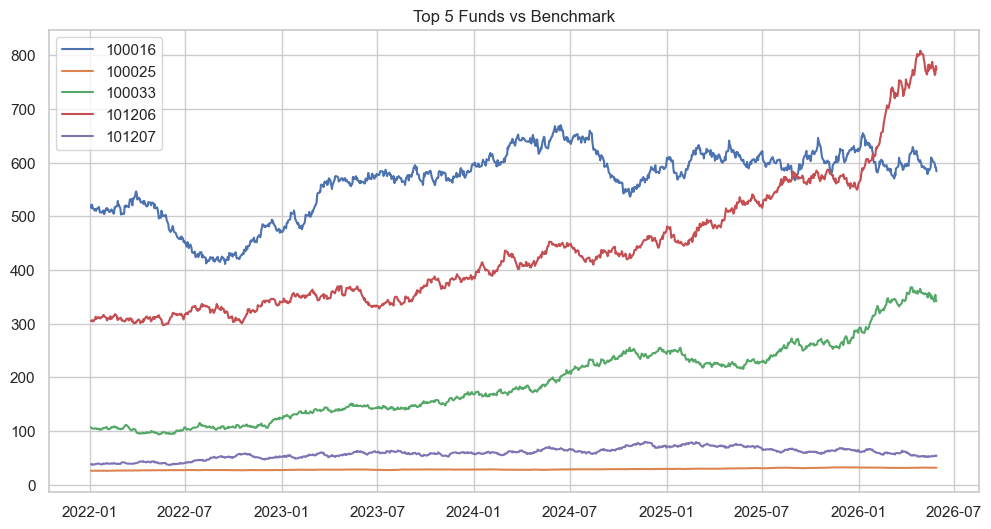

In [22]:
plt.figure(figsize=(12,6))

for fund in top5:

    df = nav_history[
        nav_history["amfi_code"] == fund
    ]

    plt.plot(
        df["date"],
        df["nav"],
        label=str(fund)
    )

plt.legend()

plt.title(
    "Top 5 Funds vs Benchmark"
)

plt.show()

In [23]:
#trackdown error

tracking_error = []

for fund in top5:

    fund_returns = (
        nav_history[
            nav_history["amfi_code"] == fund
        ]["daily_return"]
        .dropna()
    )

    min_len = min(
        len(fund_returns),
        len(benchmark_returns)
    )

    te = (
        (
            fund_returns[:min_len]
            -
            benchmark_returns[:min_len]
        )
        .std()
        *
        np.sqrt(252)
    )

    tracking_error.append(
        [fund, te]
    )

tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,100016,NaN
1,100025,NaN
2,100033,NaN
3,101206,NaN
4,101207,NaN


In [24]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [25]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

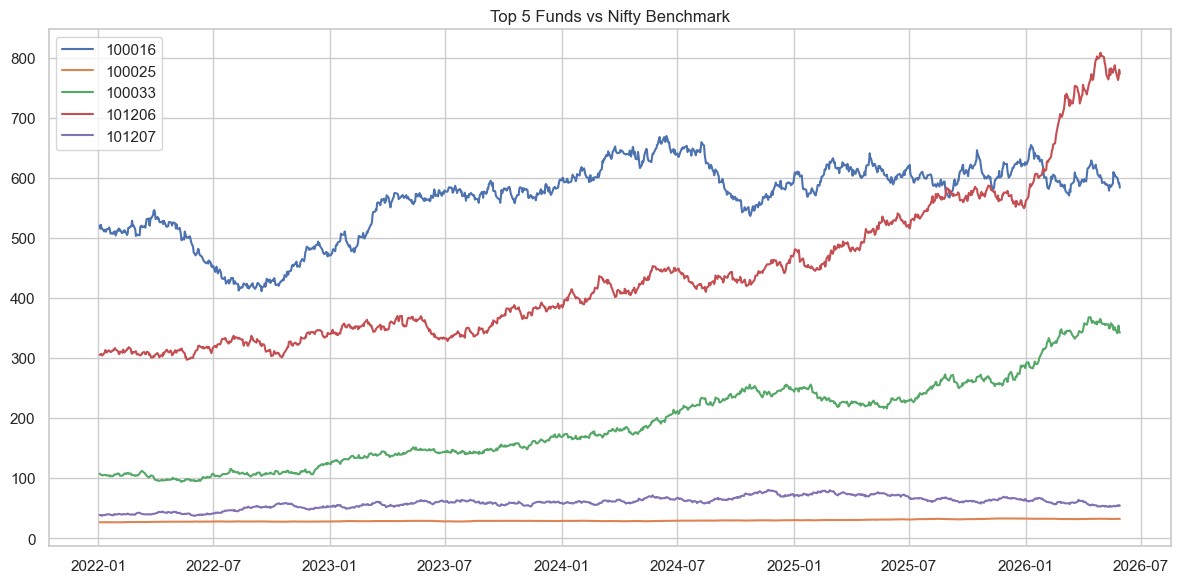

In [26]:
plt.figure(figsize=(12,6))

for fund in top5:

    df = nav_history[
        nav_history["amfi_code"] == fund
    ]

    plt.plot(
        df["date"],
        df["nav"],
        label=str(fund)
    )

plt.legend()

plt.title(
    "Top 5 Funds vs Nifty Benchmark"
)

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()